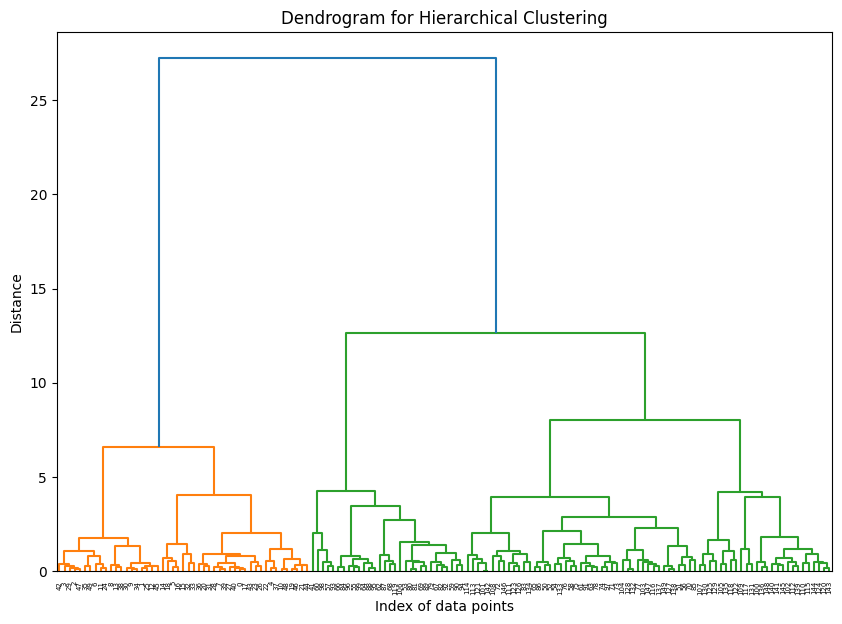

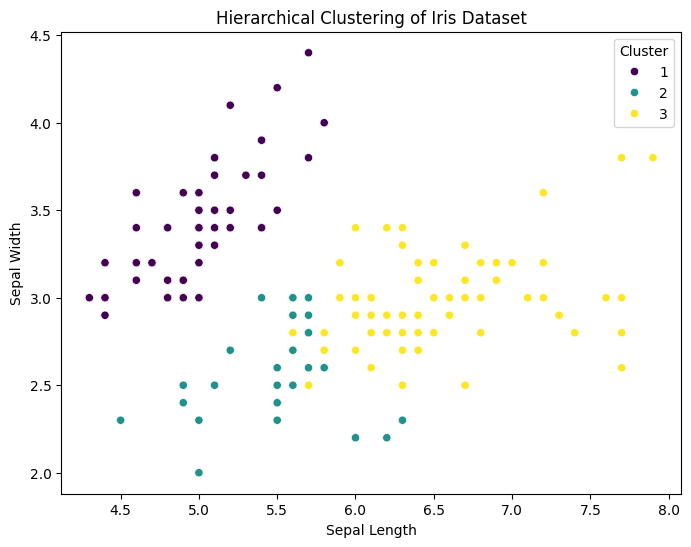

Cluster assignments: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 2 1 1 1 1 1 1 1 1 3 3 3 2 3 2 3 2 3 2 2 3 2 3 2 3 2 2 2 2 3 3 3 3
 3 3 3 3 3 2 2 2 2 3 2 3 3 2 2 2 2 3 2 2 2 2 2 3 2 2 3 3 3 3 3 3 2 3 3 3 3
 3 3 3 3 3 3 3 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3]


In [1]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Step 2: Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Labels

# Step 3: Standardize the data (optional but recommended)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Perform hierarchical clustering using 'linkage' method from scipy
Z = linkage(X_scaled, method='ward')  # You can choose 'single', 'complete', 'average', or 'ward'

# Step 5: Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Index of data points')
plt.ylabel('Distance')
plt.show()

# Step 6: Cut the dendrogram to form clusters (e.g., cut at distance threshold or a specific number of clusters)
# Let's assume we want 3 clusters (which is reasonable for the Iris dataset)
clusters = fcluster(Z, t=3, criterion='maxclust')

# Step 7: Visualize the results
# Add the cluster information to the original dataset for visualization
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['Cluster'] = clusters

# Plot the first two features with the assigned clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=iris_df.iloc[:, 0], y=iris_df.iloc[:, 1], hue=iris_df['Cluster'], palette="viridis")
plt.title('Hierarchical Clustering of Iris Dataset')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.show()

# Optionally, print the cluster centers
print("Cluster assignments:", clusters)
